# Class imbalance and metric volatility

This experiment isolates a consequence of class imbalance that is easy to overlook: when the total sample size stays fixed, a higher imbalance ratio leaves fewer minority-class observations for evaluation. Metrics calculated from those observations therefore become more variable.

We compare logistic regression and XGBoost at imbalance ratios of 100:1 and 1000:1. We then evaluate the models with repeated stratified cross-validation using either three or five folds and measure the computational cost and the standard deviation of ROC-AUC.

The standard deviation describes the dispersion of the held-out scores. Unlike the standard error of the mean, it does not mechanically shrink just because we collect more cross-validation scores. Repeated cross-validation can reveal the dispersion more reliably, but it cannot create additional minority observations or remove the underlying volatility.


In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


## Create the two datasets

The total sample size is 20,000 and the data-generating process remains fixed. Only class prevalence changes. At 100:1 we have about 199 minority observations; at 1000:1 we have about 19.

With three-fold cross-validation, each validation fold contains approximately 66 minority observations at 100:1 and 6 at 1000:1. With five folds, those numbers decrease to approximately 40 and 4. The comparison therefore tests whether putting more minority observations in each validation fold reduces metric volatility.


In [2]:
datasets = {}

for ir in [100, 1000]:
    minority_prevalence = 1 / (ir + 1)
    X, y = make_classification(
        n_samples=20_000,
        n_features=20,
        n_informative=10,
        n_redundant=5,
        weights=[1 - minority_prevalence, minority_prevalence],
        flip_y=0,
        class_sep=0.7,
        random_state=42,
    )
    datasets[ir] = (X, y)
    print(
        f"IR {ir}:1 | majority={np.sum(y == 0):,} | "
        f"minority={np.sum(y == 1):,} | "
        f"minority/fold with 3-fold≈{np.sum(y == 1) / 3:.1f} | "
        f"minority/fold with 5-fold≈{np.sum(y == 1) / 5:.1f}"
    )


IR 100:1 | majority=19,801 | minority=199 | minority/fold with 3-fold≈66.3 | minority/fold with 5-fold≈39.8
IR 1000:1 | majority=19,981 | minority=19 | minority/fold with 3-fold≈6.3 | minority/fold with 5-fold≈3.8


## Evaluate both models

For every model and imbalance ratio, we run repeated stratified cross-validation with either three or five folds. We use one, three and ten repetitions to show whether adding repetitions contains the fold-to-fold standard deviation. We also record wall-clock evaluation time.

The models use modest settings to keep the demonstration quick. All folds run sequentially so that elapsed time scales transparently with the number of model fits.


In [3]:
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42),
    ),
    "XGBoost": XGBClassifier(
        n_estimators=75,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    ),
}

rows = []
score_store = {}

for ir, (X, y) in datasets.items():
    for model_name, model in models.items():
        for folds in [3, 5]:
            for repeats in [1, 3, 10]:
                cv = RepeatedStratifiedKFold(
                    n_splits=folds,
                    n_repeats=repeats,
                    random_state=42,
                )

                start = perf_counter()
                scores = cross_val_score(
                    model, X, y, scoring="roc_auc", cv=cv, n_jobs=1
                )
                elapsed = perf_counter() - start

                rows.append({
                    "model": model_name,
                    "imbalance_ratio": ir,
                    "folds": folds,
                    "repeats": repeats,
                    "fits": len(scores),
                    "mean_roc_auc": scores.mean(),
                    "roc_auc_sd": scores.std(ddof=1),
                    "elapsed_seconds": elapsed,
                })
                score_store[(model_name, ir, folds, repeats)] = scores

results = pd.DataFrame(rows)
results.round(4)


,model,imbalance_ratio,folds,repeats,fits,mean_roc_auc,roc_auc_sd,elapsed_seconds
0,Logistic regression,100,3,1,3,0.7938,0.0483,0.0254
1,Logistic regression,100,3,3,9,0.7943,0.0275,0.0571
2,Logistic regression,100,3,10,30,0.7940,0.0233,0.1903
3,Logistic regression,100,5,1,5,0.7962,0.0406,0.0325
4,Logistic regression,100,5,3,15,0.7950,0.0335,0.0972
5,Logistic regression,100,5,10,50,0.7950,0.0402,0.3207
6,XGBoost,100,3,1,3,0.9470,0.0247,0.2138
7,XGBoost,100,3,3,9,0.9399,0.0158,0.6163
8,XGBoost,100,3,10,30,0.9381,0.0139,2.0851
9,XGBoost,100,5,1,5,0.9541,0.0208,0.3961


## First result: fewer minority examples, wider error bars

The plot uses ten repetitions and shows mean ROC-AUC ± one standard deviation across held-out folds. Bars emphasise that 100:1 and 1000:1 are two discrete experimental conditions, not points on an estimated continuous curve.


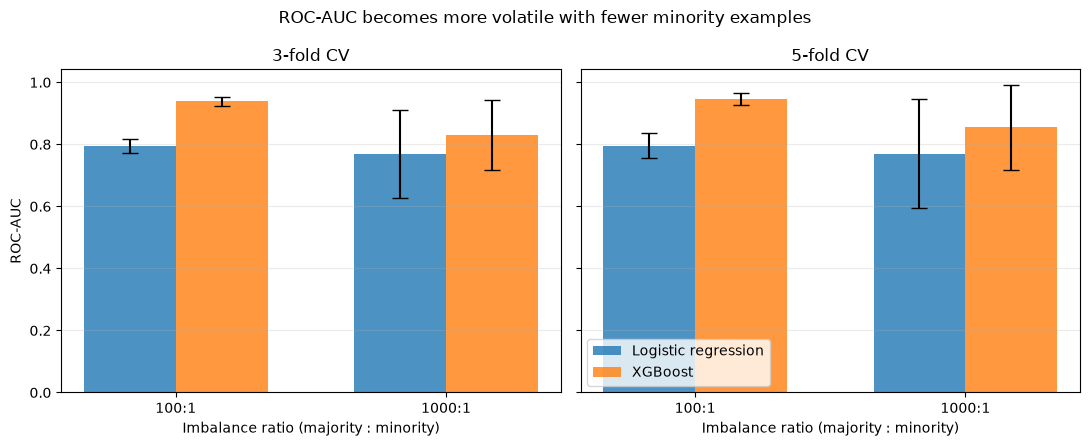

In [4]:
plot_data = results.query("repeats == 10")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

x = np.arange(2)
width = 0.34

for ax, folds in zip(axes, [3, 5]):
    fold_data = plot_data.query("folds == @folds")
    for position, (model_name, group) in enumerate(fold_data.groupby("model")):
        group = group.set_index("imbalance_ratio").loc[[100, 1000]]
        ax.bar(
            x + (position - 0.5) * width,
            group["mean_roc_auc"],
            width,
            yerr=group["roc_auc_sd"],
            capsize=6,
            alpha=0.8,
            label=model_name,
        )

    ax.set_xticks(x, ["100:1", "1000:1"])
    ax.set_xlabel("Imbalance ratio (majority : minority)")
    ax.set_title(f"{folds}-fold CV")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("ROC-AUC")
axes[1].legend()
fig.suptitle("ROC-AUC becomes more volatile with fewer minority examples")
plt.tight_layout()
plt.show()


## Do repetitions or fewer folds contain the volatility?

The left panel shows evaluation time. The right panel shows the standard deviation of the held-out ROC-AUC scores—not the standard error. If repetitions solved the volatility problem, the curves in the right panel would decrease consistently as repetitions increased.

Comparing three and five folds addresses a different lever. Three-fold CV places more minority observations in every validation fold, which may reduce evaluation volatility, but it also trains each model on a smaller fraction of the data.


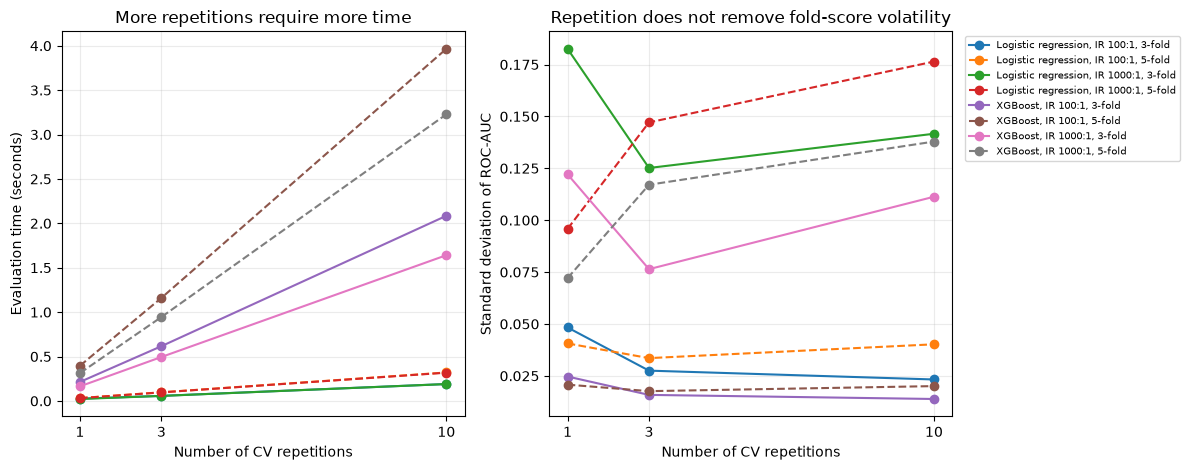

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
styles = {3: "-", 5: "--"}

for (model_name, ir, folds), group in results.groupby(
    ["model", "imbalance_ratio", "folds"]
):
    group = group.sort_values("repeats")
    label = f"{model_name}, IR {ir}:1, {folds}-fold"
    axes[0].plot(
        group["repeats"], group["elapsed_seconds"],
        marker="o", linestyle=styles[folds], label=label,
    )
    axes[1].plot(
        group["repeats"], group["roc_auc_sd"],
        marker="o", linestyle=styles[folds], label=label,
    )

axes[0].set_title("More repetitions require more time")
axes[0].set_xlabel("Number of CV repetitions")
axes[0].set_ylabel("Evaluation time (seconds)")

axes[1].set_title("Repetition does not remove fold-score volatility")
axes[1].set_xlabel("Number of CV repetitions")
axes[1].set_ylabel("Standard deviation of ROC-AUC")

for ax in axes:
    ax.set_xticks([1, 3, 10])
    ax.grid(alpha=0.25)

axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Compact results table

The table reports evaluation time and ROC-AUC dispersion for both fold choices. The ten-repeat rows provide the most stable description of the score distribution because they are based on 30 scores with three-fold CV and 50 scores with five-fold CV.


In [6]:
summary = results.copy()
summary["mean ± SD"] = summary.apply(
    lambda row: f'{row["mean_roc_auc"]:.3f} ± {row["roc_auc_sd"]:.3f}', axis=1
)

summary[[
    "model",
    "imbalance_ratio",
    "folds",
    "repeats",
    "fits",
    "mean ± SD",
    "elapsed_seconds",
]].round({"elapsed_seconds": 2})


,model,imbalance_ratio,folds,repeats,fits,mean ± SD,elapsed_seconds
0,Logistic regression,100,3,1,3,0.794 ± 0.048,0.03
1,Logistic regression,100,3,3,9,0.794 ± 0.028,0.06
2,Logistic regression,100,3,10,30,0.794 ± 0.023,0.19
3,Logistic regression,100,5,1,5,0.796 ± 0.041,0.03
4,Logistic regression,100,5,3,15,0.795 ± 0.034,0.10
5,Logistic regression,100,5,10,50,0.795 ± 0.040,0.32
6,XGBoost,100,3,1,3,0.947 ± 0.025,0.21
7,XGBoost,100,3,3,9,0.940 ± 0.016,0.62
8,XGBoost,100,3,10,30,0.938 ± 0.014,2.09
9,XGBoost,100,5,1,5,0.954 ± 0.021,0.40


## Three-fold versus five-fold CV after ten repetitions

This focused table makes the mitigation comparison easier to inspect. A smaller standard deviation favours that fold choice for evaluation stability; the mean ROC-AUC and training-set-size trade-off must still be considered.


In [7]:
fold_comparison = (
    results.query("repeats == 10")
    .pivot(
        index=["model", "imbalance_ratio"],
        columns="folds",
        values=["mean_roc_auc", "roc_auc_sd", "elapsed_seconds"],
    )
)
fold_comparison.round(4)


mean_roc_auc         roc_auc_sd          \
folds                                          3       5          3       5   
model               imbalance_ratio                                           
Logistic regression 100                   0.7940  0.7950     0.0233  0.0402   
                    1000                  0.7676  0.7697     0.1416  0.1764   
XGBoost             100                   0.9381  0.9457     0.0139  0.0201   
                    1000                  0.8300  0.8543     0.1113  0.1379   

                                    elapsed_seconds          
folds                                             3       5  
model               imbalance_ratio                          
Logistic regression 100                      0.1903  0.3207  
                    1000                     0.1900  0.3182  
XGBoost             100                      2.0851  3.9654  
                    1000                     1.6412  3.2279

## Conclusions

1. With 20,000 total observations, increasing the imbalance ratio from 100:1 to 1000:1 reduces the minority class from 199 to 19 observations.
2. At 1000:1, each validation fold contains only about six minority observations with three-fold CV and four with five-fold CV. Consequently, the composition of a fold has a large effect on ROC-AUC.
3. Increasing the number of repetitions does not systematically reduce the standard deviation. It provides more evidence about the score distribution, at the cost of more model fits.
4. Using three rather than five folds gives each validation fold more minority observations and can reduce volatility. The trade-off is that every model is trained on two-thirds rather than four-fifths of the data, which can change both fitted performance and bias.
5. Changing the number of folds redistributes the same limited observations; it does not add information. More minority data, a larger independent evaluation set, or an evaluation design chosen around a minimum number of minority outcomes is a more direct remedy.
